# Run entropy score and cosine score on neg neg
The cleaned notebook alreaedy does comparison with modified cosine score, here we also did run entropy score and normal cosine. 

In [3]:
import numpy as np
from tqdm import tqdm
from matchms.similarity.vector_similarity_functions import jaccard_similarity_matrix


In [4]:
import os
import pickle

pickled_intermediates_data_folder = "./pickled_intermediates_neg"

# Load the pickled files
with open(os.path.join(pickled_intermediates_data_folder, "val.pickle"), "rb") as handle:
    val_neg = pickle.load(handle)

Your CPU supports instructions that this binary was not compiled to use: SSE3 SSE4.1 SSE4.2 AVX AVX2
For maximum performance, you can install NMSLIB from sources 
pip install --no-binary :all: nmslib


In [5]:
with open(os.path.join(pickled_intermediates_data_folder, "train.pickle"), "rb") as handle:
    train_neg = pickle.load(handle)

In [6]:
from ms2query.benchmarking.Fingerprints import Fingerprints
val_fingerprints = Fingerprints.from_spectrum_set(val_neg, "daylight", 4096)
train_fingerprints = Fingerprints.from_spectrum_set(train_neg, "daylight", 4096)
fingerprints = Fingerprints.combine_fingerprints(val_fingerprints, train_fingerprints)

Get most common inchi per inchikey: 100%|██████████████████████████████████████████████████████████████| 1614/1614 [00:00<00:00, 36199.94it/s]
Adding fingerprints to Inchikeys: 1614it [00:07, 216.45it/s]
Get most common inchi per inchikey: 100%|████████████████████████████████████████████████████████████| 29806/29806 [00:00<00:00, 35219.38it/s]
Adding fingerprints to Inchikeys: 29806it [01:42, 291.85it/s]


In [18]:
from tqdm import tqdm
from matchms.similarity.vector_similarity_functions import jaccard_similarity_matrix

def get_prediction_tanimoto(predicted_inchikeys, val_spectra, val_and_train_fingerprints):
    assert len(predicted_inchikeys) == len(val_spectra)

    tanimoto_for_prediction = []
    for index, predicted_inchikey in enumerate(tqdm(predicted_inchikeys)):
        if predicted_inchikey is not None:
            correct_inchikey = val_spectra.spectra[index].get("inchikey")[:14]
            predicted_fingerprint = val_and_train_fingerprints.get_fingerprints([predicted_inchikey])[0]
            actual_fingerprint = val_and_train_fingerprints.get_fingerprints([correct_inchikey])[0]
            tanimoto_prediction = jaccard_similarity_matrix(np.array([predicted_fingerprint]), np.array([actual_fingerprint]))[0][0]
            tanimoto_for_prediction.append(tanimoto_prediction)
        else:
            tanimoto_for_prediction.append(0.0)
    return tanimoto_for_prediction

In [28]:
def get_average_tanimoto_after_filtering(
        query_spectrum_set, tanimoto_for_predictions
) -> float:
    """Calculates the average tanimoto of predictions made per inchikey. 
    """
    assert len(tanimoto_for_predictions) == len(query_spectrum_set)
    average_scores_per_inchikey = []
    # Calculate score per unique inchikey
    for inchikey in query_spectrum_set.spectrum_indices_per_inchikey.keys():
        matching_spectrum_indexes = query_spectrum_set.spectrum_indices_per_inchikey[inchikey]
        prediction_scores = []
        for index in matching_spectrum_indexes:
            tanimoto_for_prediction = tanimoto_for_predictions[index]
            if tanimoto_for_prediction is not None:
                prediction_scores.append(tanimoto_for_prediction)
        if len(prediction_scores) > 0:
            average_prediction = sum(prediction_scores) / len(prediction_scores)
            average_scores_per_inchikey.append(average_prediction)
    average_over_all_inchikeys = sum(average_scores_per_inchikey) / len(average_scores_per_inchikey)
    return average_over_all_inchikeys


def get_average_tanimoto_after_treshold(query_spectrum_set,
                                        tanimoto_for_predictions, predicted_scores, threshold):
    """Applies a threshold and calculates the average tanimoto. It returns both the fraction that passed the threshold and average tanimoto."""

    selected_tanimoto_scores = []
    nr_of_predictions = 0
    for index, score in enumerate(predicted_scores):
        if score > threshold:
            selected_tanimoto_scores.append(tanimoto_for_predictions[index])
            nr_of_predictions += 1
        else:
            selected_tanimoto_scores.append(None)
    prediction_fraction = nr_of_predictions/len(tanimoto_for_predictions)
    average_tanimoto = get_average_tanimoto_after_filtering(query_spectrum_set, selected_tanimoto_scores)
    return prediction_fraction, average_tanimoto

def get_average_tanimoto_for_list_of_thresholds(query_spectrum_set, 
                                                tanimoto_for_predictions, predicted_scores):
    assert len(predicted_scores) == len(tanimoto_for_predictions) == len(query_spectrum_set)
    list_of_thresholds = np.quantile(predicted_scores, np.linspace(0.0, 0.98, 100))
    prediction_fractions = []
    average_tanimotos = []
    for threshold in tqdm(list_of_thresholds, desc = "thresholds"):
        prediction_fraction, average_tanimoto = get_average_tanimoto_after_treshold(query_spectrum_set, tanimoto_for_predictions, predicted_scores, threshold)
        prediction_fractions.append(prediction_fraction)
        average_tanimotos.append(average_tanimoto)
    return prediction_fractions, average_tanimotos


In [32]:
from matchms.similarity.FlashSimilarity import FlashSimilarity
import numpy as np
def get_inchikeys_and_predicted_scores(similarity_method, train, val, fingerprints):
    score_matrix = similarity_method.matrix(train.spectra, val.spectra)
    max_indices = np.argmax(score_matrix, axis=0)
    predicted_score = score_matrix[max_indices, np.arange(score_matrix.shape[1])]
    predicted_inchikeys = []
    for index in max_indices:
        predicted_inchikeys.append(train.spectra[index].get("inchikey")[:14])
    tanimoto_for_predictions = get_prediction_tanimoto(predicted_inchikeys, val, fingerprints)
    return tanimoto_for_predictions, predicted_score


In [23]:
prediction_tanimoto_entropy_hybrid, predicted_scores_entropy_hybrid = get_inchikeys_and_predicted_scores(FlashSimilarity("spectral_entropy", "hybrid", remove_precursor=True), train_neg, val_neg, fingerprints)
prediction_fractions_entropy_hybrid, average_tanimotos_entropy_hybrid = get_average_tanimoto_for_list_of_thresholds(val_neg, prediction_tanimoto_entropy_hybrid, predicted_scores_entropy_hybrid)

100%|████████████████████████████████████████████████████████████████████████████████████████████████| 15967/15967 [00:00<00:00, 15991.10it/s]


In [33]:
prediction_tanimoto_mod_cos, max_scores_mod_cos = get_inchikeys_and_predicted_scores(FlashSimilarity("cosine", "hybrid", remove_precursor=True), train_neg, val_neg, fingerprints)
prediction_fractions_mod_cos, average_tanimotos_mod_cos = get_average_tanimoto_for_list_of_thresholds(val_neg, prediction_tanimoto_mod_cos, max_scores_mod_cos)

thresholds: 100%|██████████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:00<00:00, 389.50it/s]


In [34]:
prediction_tanimoto_cos, max_scores_cos = get_inchikeys_and_predicted_scores(FlashSimilarity("cosine", "fragment", remove_precursor=True), train_neg, val_neg, fingerprints)
prediction_fractions_cos, average_tanimotos_cos = get_average_tanimoto_for_list_of_thresholds(val_neg, prediction_tanimoto_cos, max_scores_cos)

thresholds: 100%|██████████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:00<00:00, 394.65it/s]


In [35]:
prediction_tanimoto_entropy, max_scores_entropy = get_inchikeys_and_predicted_scores(FlashSimilarity("spectral_entropy", "fragment", remove_precursor=True), train_neg, val_neg, fingerprints)
prediction_fractions_entropy, average_tanimotos_entropy = get_average_tanimoto_for_list_of_thresholds(val_neg, prediction_tanimoto_entropy, max_scores_entropy)

thresholds: 100%|██████████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:00<00:00, 396.78it/s]


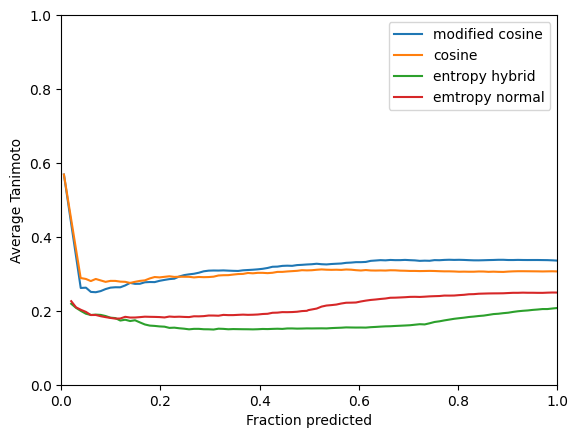

In [36]:
from matplotlib import pyplot as plt
plt.plot(prediction_fractions_mod_cos, average_tanimotos_mod_cos, label = "modified cosine")
plt.plot(prediction_fractions_cos, average_tanimotos_cos, label = "cosine")
plt.plot(prediction_fractions_entropy_hybrid, average_tanimotos_entropy_hybrid, label = "entropy hybrid")
plt.plot(prediction_fractions_entropy, average_tanimotos_entropy, label = "emtropy normal")

plt.xlabel("Fraction predicted")
plt.ylabel("Average Tanimoto")
plt.legend()
plt.xlim((0, 1))
plt.ylim((0, 1))
plt.show()